# Youth neither in employment nor in education

In [3]:
import pandas as pd

youth_unemplyment = pd.read_csv('edat_lfse_20_linear_2_0.csv')
youth_unemplyment.sample(1)

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,freq,Time frequency,sex,Sex,age,Age class,training,...,geo,Geopolitical entity (reporting),TIME_PERIOD,Time,OBS_VALUE,Observation value,OBS_FLAG,Observation status (Flag) V2 structure,CONF_STATUS,Confidentiality status (flag)
8176,dataflow,ESTAT:EDAT_LFSE_20(1.0),Young persons neither in employment nor in edu...,A,Annual,F,Females,Y15-19,From 15 to 19 years,NO_FE_NO_NFE,...,IT,Italy,2021,NaN,4.6,NaN,b,break in time series,NaN,NaN


In [17]:
youth_unemplyment_romania = youth_unemplyment[youth_unemplyment.geo == 'RO'][['sex', 'age', 'Age class', 'geo', 'Geopolitical entity (reporting)', 'wstatus', 'Labour force and employment status', 'TIME_PERIOD', 'OBS_VALUE']]
youth_unemplyment_romania.sample(5)

,sex,age,Age class,geo,Geopolitical entity (reporting),wstatus,Labour force and employment status,TIME_PERIOD,OBS_VALUE
29940,F,Y18-29,From 18 to 29 years,RO,Romania,WANT,Persons would like to work (seeking employment...,2016,10.7
97038,M,Y25-34,From 25 to 34 years,RO,Romania,NWANT,Persons do not want to work,2024,6.2
138301,T,Y20-34,From 20 to 34 years,RO,Romania,INAC,Persons outside the labour force,2001,15.1
17031,F,Y15-29,From 15 to 29 years,RO,Romania,WANT,Persons would like to work (seeking employment...,2022,6.5
17891,F,Y15-34,From 15 to 34 years,RO,Romania,INAC,Persons outside the labour force,2021,25.7


In [13]:
youth_unemplyment_romania['Labour force and employment status'].unique()

array(['Persons outside the labour force', 'Not employed persons',
       'Persons do not want to work', 'Unemployed persons',
       'Persons would like to work (seeking employment or not)'],
      dtype=object)

In [39]:
# I will take only the unemplyed people and the ones from 18 to 29
youth_unemplyed_romania = youth_unemplyment[(youth_unemplyment.geo == 'RO') & (youth_unemplyment.wstatus == 'NEMP') & (youth_unemplyment.age == 'Y18-24') & (youth_unemplyment.sex == 'T')][['sex', 'age', 'Age class', 'geo', 'Geopolitical entity (reporting)', 'wstatus', 'Labour force and employment status', 'TIME_PERIOD', 'OBS_VALUE']]
youth_unemplyed_romania.head()

,sex,age,Age class,geo,Geopolitical entity (reporting),wstatus,Labour force and employment status,TIME_PERIOD,OBS_VALUE
126246,T,Y18-24,From 18 to 24 years,RO,Romania,NEMP,Not employed persons,2000,25.6
126247,T,Y18-24,From 18 to 24 years,RO,Romania,NEMP,Not employed persons,2001,23.4
126248,T,Y18-24,From 18 to 24 years,RO,Romania,NEMP,Not employed persons,2002,27.9
126249,T,Y18-24,From 18 to 24 years,RO,Romania,NEMP,Not employed persons,2003,26.7
126250,T,Y18-24,From 18 to 24 years,RO,Romania,NEMP,Not employed persons,2004,24.6


([<matplotlib.axis.XTick at 0x16b6e968640>,
 [Text(2017, 0, '2017'),
  Text(2018, 0, '2018'),
  Text(2019, 0, '2019'),
  Text(2020, 0, '2020'),
  Text(2021, 0, '2021'),
  Text(2022, 0, '2022'),
  Text(2023, 0, '2023'),
  Text(2024, 0, '2024')])

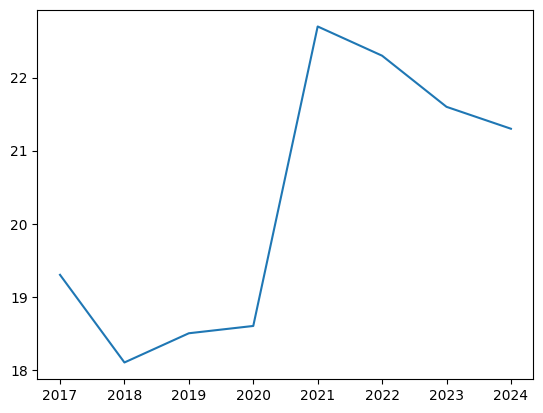

In [44]:
import matplotlib.pyplot as plt

df = youth_unemplyed_romania[youth_unemplyed_romania.TIME_PERIOD > 2016]

plt.plot(df.TIME_PERIOD, df.OBS_VALUE)
plt.xticks(df.TIME_PERIOD)